# Dijkstra

Thuật toán **Dijkstra** giải bài toán **đường đi ngắn nhất một nguồn** (single-source shortest path) trên đồ thị có trọng số **không âm**. 

Xét một **đồ thị có hướng** với \(N\) đỉnh (đánh số từ \(0\) đến \(N-1\)), \(M\) cạnh có hướng kèm trọng số, và một đỉnh nguồn \(S\). Mục tiêu là tìm khoảng cách ngắn nhất từ \(S\) đến mọi đỉnh khác, với giả thiết **mọi trọng số cạnh đều không âm**.

### Input
```text
7 8 0
0 2 7
0 1 1
0 3 4
2 5 8
5 3 3
4 5 6
1 4 3
2 4 3
```

### Output
```text
0
1
7
4
4
10
-1
```

Hình ảnh của Test ví dụ. Ở đồ thị này, đỉnh nguồn là đỉnh 0, đường đi ngắn nhất từ 0 đến các đỉnh 0 đến 5 là [0, 1, 7, 4, 4, 10]. Riêng đỉnh 6 không có đường đi đến.

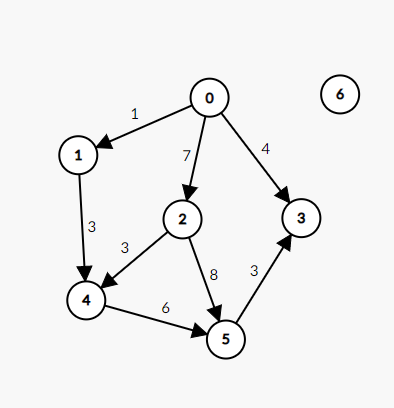

## Ý tưởng của thuật toán

Ý tưởng chính của thuật toán Dijkstra là tối ưu hóa đường đi bằng cách xét các cạnh (u, v), so sánh hai đường đi S → v sẵn có với đường đi S → u → v.

Thuật toán duy trì một mảng lưu khoảng cách ngắn nhất từ S đến tất cả các đỉnh. Ở mỗi bước, chọn đỉnh u có khoảng cách S → u **nhỏ nhất** trong số các đỉnh **chưa được xử lý**. Sau đó, kiểm tra và cập nhật đường đi S → v bằng cách thử S → u → v. Vì S → u là đường đi ngắn nhất đã được chọn nên không cần kiểm tra lại và đỉnh u được đánh dấu là **đã xử lý**. Lặp lại các bước trên với các đỉnh còn lại cho đến khi **tất cả** các đỉnh đều được xử lý.

## Minh họa thuật toán

Ta sẽ minh họa thuật toán bằng một đồ thị như hình. Định nghĩa:

- **D_u** là đường đi ngắn nhất từ đỉnh nguồn đến đỉnh *u* đã tìm được.
- **P_u** nhận hai giá trị `true`, `false` cho biết đỉnh *u* đã được chọn để tối ưu chưa.

**Đỉnh được tô đen (đỉnh 0) sẽ là đỉnh nguồn.**

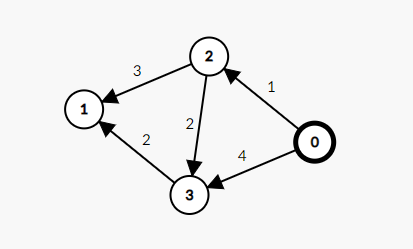

**Ban đầu**, D = [0, ∞, ∞, ∞], P = [false, false, false, false]

- **Bước 1:** Thuật toán chọn đỉnh 0, vì D₀ = 0 là nhỏ nhất và P₀ = false. Tối ưu các cạnh đi ra:
  - Cạnh (0, 2): cập nhật D₂ = min(D₂, D₀ + W₀,₂) = min(∞, 0 + 1) = 1
  - Cạnh (0, 3): cập nhật D₃ = min(D₃, D₀ + W₀,₃) = min(∞, 0 + 4) = 4

  **Sau bước này**, D = [0, ∞, 1, 4], P = [true, false, false, false]

- **Bước 2:** Thuật toán chọn đỉnh 2, do D₂ = 1 là nhỏ nhất và P₂ = false. Tối ưu các cạnh đi ra:
  - Cạnh (2, 1): cập nhật D₁ = min(D₁, D₂ + W₂,₁) = min(∞, 1 + 3) = 4
  - Cạnh (2, 3): cập nhật D₃ = min(D₃, D₂ + W₂,₃) = min(4, 1 + 2) = 3

  **Sau bước này**, D = [0, 4, 1, 3], P = [true, false, true, false]

- **Bước 3:** Thuật toán chọn đỉnh 3, do D₃ = 3 là nhỏ nhất và P₃ = false. Tối ưu các cạnh đi ra:
  - Cạnh (3, 1): cập nhật D₁ = min(D₁, D₃ + W₃,₁) = min(4, 3 + 2) = 4

  **Sau bước này**, D = [0, 4, 1, 3], P = [true, false, true, true]

- **Bước 4:** Thuật toán chọn đỉnh 1. **Không** có cạnh nào đi ra.

Đến đây, tất cả các đỉnh đều đã được đánh dấu. **Kết quả**: đường đi ngắn nhất tìm được từ đỉnh 0 là  
D = [0, 4, 1, 3].


## Cài đặt

Ở thuật toán này, ta sẽ lưu đồ thị dưới dạng **danh sách kề**. Ta định nghĩa như sau:

- `D[u]` là đường đi ngắn nhất từ `s` đến `u`. Ban đầu khởi tạo `D[u] = ∞` với mọi `u`, riêng `D[s] = 0`.
- `W[u, v]` là trọng số cạnh trên đường đi từ `u` đến `v`.
- `P[u]` là mảng đánh dấu các đỉnh đã được xử lý chưa. Ban đầu tất cả các giá trị đều là `false`.
- Trong trường hợp bài toán yêu cầu truy vết, ta có thể định nghĩa thêm một mảng `trace`, trong đó `trace[u]` là đỉnh nằm trước đỉnh `u` trên đường đi ngắn nhất từ `s` đến `u`.

Ta sẽ lặp **N** lần quá trình sau:

- Tìm đỉnh `u` có `D[u]` nhỏ nhất và `P[u] = false`.
- Sau khi tìm được đỉnh `u`, xét các đỉnh `v` kề với `u` và tiến hành tối ưu hóa `D[v]`:  
  nếu `D[v] > D[u] + W[u, v]` thì gán `D[v] = D[u] + W[u, v]`.
- Nếu việc tối ưu hóa diễn ra, cập nhật `trace[v] = u`.
- Đánh dấu `P[u] = true`, nghĩa là đỉnh `u` đã được xử lý xong.

## Độ phức tạp thuật toán

Trong quá trình tính toán, ta thực hiện **N** lần lặp:

- Bước đầu tiên có độ phức tạp **O(N)** *mỗi lần lặp*.
- Bước thứ hai có **tổng** độ phức tạp **O(M)** *qua tất cả các lần lặp*.

Như vậy, độ phức tạp của cách cài đặt cơ bản sẽ là **O(N^2 + M)**.



In [2]:
INF = 2_000_000_000_000_000_000  # 2000000000000000000

# E: danh sách kề kiểu List[List[Tuple[v, w]]]
def dijkstra(n, S, E):
    D = [INF] * n
    trace = [-1] * n
    P = [False] * n
    D[S] = 0

    for _ in range(n):
        # tìm đỉnh u chưa dùng, có khoảng cách nhỏ nhất
        uBest = -1
        Min = INF
        for u in range(n):
            if not P[u] and D[u] < Min:
                Min = D[u]
                uBest = u

        if uBest == -1:  # không còn đỉnh nào có thể cải thiện
            break

        # cải tiến các đường đi qua u
        u = uBest
        P[u] = True
        for v, w in E[u]:
            if D[v] > D[u] + w:
                D[v] = D[u] + w
                trace[v] = u

    return D, trace


Đồ thị vô hướng (cạnh đi 2 chiều), các cạnh và trọng số đúng như ảnh “kinh điển” của Dijkstra:

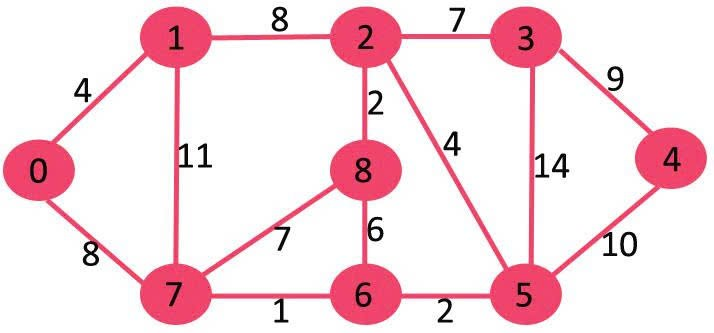

# 🧮 Thuật toán Dijkstra — Minh hoạ từng bước trên đồ thị kinh điển

---

## 🔹 Cấu trúc đồ thị (vô hướng)
Đồ thị có 9 đỉnh (0–8) và các cạnh 2 chiều như sau:

| Đỉnh | Các cạnh kề (trọng số) |
|------|-------------------------|
| 0 | 0–1(4), 0–7(8) |
| 1 | 1–2(8), 1–7(11) |
| 2 | 2–3(7), 2–8(2), 2–5(4) |
| 3 | 3–4(9), 3–5(14) |
| 4 | 4–5(10) |
| 5 | 5–6(2) |
| 6 | 6–7(1), 6–8(6) |
| 7 | 7–8(7) |

---

## 🔹 Ký hiệu

| Ký hiệu | Ý nghĩa |
|----------|----------|
| `D[u]` | khoảng cách ngắn nhất hiện biết từ đỉnh nguồn (0) đến u |
| `P[u]` | cờ đánh dấu — đỉnh u đã được xử lý (✅) hay chưa (❌) |
| `par[u]` | đỉnh cha (truy vết ngược đường đi ngắn nhất) |

---

## 🔰 Khởi tạo ban đầu

| Mảng | Giá trị |
|-------|----------|
| `D` | [0, ∞, ∞, ∞, ∞, ∞, ∞, ∞, ∞] |
| `P` | [F, F, F, F, F, F, F, F, F] |
| `par` | [-, -, -, -, -, -, -, -, -] |

---

## ⚙️ Bước 1 — Chọn đỉnh **0**

- Vì `D[0] = 0` là nhỏ nhất ⇒ chọn đỉnh 0.  
- Cập nhật các đỉnh kề:
  - (0 → 1, 4) ⇒ `D[1] = 4`, `par[1] = 0`
  - (0 → 7, 8) ⇒ `D[7] = 8`, `par[7] = 0`

**Kết quả sau bước 1:**

`D = [0, 4, ∞, ∞, ∞, ∞, ∞, 8, ∞]`  
`P = [T, F, F, F, F, F, F, F, F]`

---

## ⚙️ Bước 2 — Chọn đỉnh **1 (D[1] = 4)**

- Cập nhật:
  - (1 → 2, 8) ⇒ `D[2] = 12`, `par[2] = 1`
  - (1 → 7, 11) ⇒ không cập nhật (vì 8 < 15)

**Sau bước 2:**  
`D = [0, 4, 12, ∞, ∞, ∞, ∞, 8, ∞]`  
`P = [T, T, F, F, F, F, F, F, F]`

---

## ⚙️ Bước 3 — Chọn đỉnh **7 (D[7] = 8)**

- Cập nhật:
  - (7 → 6, 1) ⇒ `D[6] = 9`, `par[6] = 7`
  - (7 → 8, 7) ⇒ `D[8] = 15`, `par[8] = 7`

**Sau bước 3:**  
`D = [0, 4, 12, ∞, ∞, ∞, 9, 8, 15]`  
`P = [T, T, F, F, F, F, T, T, F]`

---

## ⚙️ Bước 4 — Chọn đỉnh **6 (D[6] = 9)**

- Cập nhật:
  - (6 → 5, 2) ⇒ `D[5] = 11`, `par[5] = 6`
  - (6 → 8, 6) ⇒ không cập nhật (15 < 15)

**Sau bước 4:**  
`D = [0, 4, 12, ∞, ∞, 11, 9, 8, 15]`  
`P = [T, T, F, F, F, F, T, T, F]`

---

## ⚙️ Bước 5 — Chọn đỉnh **5 (D[5] = 11)**

- Cập nhật:
  - (5 → 2, 4) ⇒ không cập nhật (12 < 15)
  - (5 → 3, 14) ⇒ `D[3] = 25`, `par[3] = 5`
  - (5 → 4, 10) ⇒ `D[4] = 21`, `par[4] = 5` ✅ (đã tới đích lần đầu)

**Sau bước 5:**  
`D = [0, 4, 12, 25, 21, 11, 9, 8, 15]`  
`P = [T, T, T, F, F, T, T, T, F]`

---

## ⚙️ Bước 6 — Chọn đỉnh **2 (D[2] = 12)**

- Cập nhật:
  - (2 → 3, 7) ⇒ `D[3] = min(25, 19)` ⇒ `D[3] = 19`, `par[3] = 2`
  - (2 → 8, 2) ⇒ `D[8] = min(15, 14)` ⇒ `D[8] = 14`, `par[8] = 2`

**Sau bước 6:**  
`D = [0, 4, 12, 19, 21, 11, 9, 8, 14]`  
`P = [T, T, T, F, F, T, T, T, F]`

---

## ⚙️ Bước 7 — Chọn đỉnh **8 (D[8] = 14)**

- Cạnh (8 → 6, 6) và (8 → 7, 7) đều không giúp rút ngắn đường đi.

`P[8] = T`

---

## ⚙️ Bước 8 — Chọn đỉnh **3 (D[3] = 19)**

- Cạnh (3 → 4, 9): 21 < 28 ⇒ không cập nhật.  
- Cạnh (3 → 5, 14): không cập nhật.

`P[3] = T`

---

## ✅ Kết quả cuối cùng

**Khoảng cách ngắn nhất từ 0 → 4 là 21**  
**Đường đi:** `⇒ 0 → 7 → 6 → 5 → 4`	

In [ ]:
INF = 2_000_000_000_000_000_000  # 2e18

# E: danh sách kề kiểu List[List[Tuple(v, w)]]
def dijkstra(n, S, E):
    D = [INF] * n        # D[u]: khoảng cách ngắn nhất tạm thời từ S đến u
    trace = [-1] * n     # trace[u]: đỉnh ngay trước u trên đường đi ngắn nhất
    P = [False] * n      # P[u]: đã "khóa" (xử lý xong) u hay chưa
    D[S] = 0

    for _ in range(n):
        # (1) Chọn uBest: đỉnh chưa xử lý có D[u] nhỏ nhất
        uBest = -1
        Min = INF
        for u in range(n):
            if (not P[u]) and D[u] < Min:
                Min = D[u]
                uBest = u

        if uBest == -1:           # không còn đỉnh nào có thể cải thiện
            break

        # (2) Nới lỏng các cạnh đi ra từ uBest
        u = uBest
        P[u] = True               # chốt u: khoảng cách tới u đã là ngắn nhất
        for v, w in E[u]:
            if (not P[v]) and D[v] > D[u] + w:
                D[v] = D[u] + w
                trace[v] = u

    return D, trace


# ==== DỮ LIỆU ĐỒ THỊ (vô hướng) GIỐNG HÌNH KINH ĐIỂN ===
# Cạnh và trọng số:
# 0–1(4), 0–7(8)
# 1–2(8), 1–7(11)
# 2–3(7), 2–8(2), 2–5(4)
# 3–4(9), 3–5(14)
# 4–5(10)
# 5–6(2)
# 6–7(1), 6–8(6)
# 7–8(7)

n = 9
E = [[] for _ in range(n)]

def add_undirected(u, v, w):
    E[u].append((v, w))
    E[v].append((u, w))

add_undirected(0,1,4);  add_undirected(0,7,8)
add_undirected(1,2,8);  add_undirected(1,7,11)
add_undirected(2,3,7);  add_undirected(2,8,2); add_undirected(2,5,4)
add_undirected(3,4,9);  add_undirected(3,5,14)
add_undirected(4,5,10)
add_undirected(5,6,2)
add_undirected(6,7,1);  add_undirected(6,8,6)
add_undirected(7,8,7)


# =============== CHẠY BÀI TẬP: TÌM 0 -> 4 ===============
S, T = 0, 4
D, trace = dijkstra(n, S, E)

# Truy vết đường đi từ S tới T qua mảng trace[]
path = []
cur = T
while cur != -1:
    path.append(cur)
    if cur == S:
        break
    cur = trace[cur]
if not path or path[-1] != S:
    path = []  # không đến được

# In kết quả
if path:
    path.reverse()
    print("Khoảng cách ngắn nhất {} → {}: {}".format(S, T, D[T]))
    print("Đường đi:", " -> ".join(map(str, path)))
else:
    print("Không có đường đi từ {} tới {}".format(S, T))

Khoảng cách ngắn nhất 0 → 4: 21
Đường đi: 0 -> 7 -> 6 -> 5 -> 4
